# Controlled changes at mec_k=1

The ablations of [two_track_figure.ipynb](two_track_figure.ipynb), rebuilt from one
sample per direction instead of three, and measured against the **same reference as
that figure** — the un-ablated k=3 run. The strip therefore prints the same numbers
in both figures, and a row here is what you get by switching to one sample *and*
applying the change.

The first row is the sampling change on its own, so the two effects can be told
apart: same row in the two figures differs by roughly what that row's cell here
differs from the first row.

In [22]:
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "src").is_dir() and (p / "output").is_dir())
sys.path.insert(0, str(ROOT / "src"))

from novelty_eval.figures.common import (
    EDGE_IN, FONT_STACK, PDF_RCPARAMS, TwoTrackFigure, save_figure)

plt.rcParams.update({"font.family": "sans-serif", "font.sans-serif": FONT_STACK,
                     **PDF_RCPARAMS})
print(ROOT)

/Users/noysternlicht/myCode/novelty-eval


In [23]:
ROWS = [("current", "Sampling depth only\n(mec_k = 1)"),
        ("vague_criterion", "P1 · Criteria without\nguardrails"),
        ("no_criteria_prompt", "P2 · Criteria removed"),
        ("ai_researcher_base", 'P3 · "Which was\njudged novel?"', ("pairwise",)),
        ("ai_researcher_no_review", 'P4 · "Which is novel?"', ("pairwise",)),
        ("ai_researcher_comparative", 'P5 · "Which was judged\n more novel?"', ("pairwise",)),
        ("retrieval", "+ Related work\n(retrieval)"),
        ("low_judge_reasoning", "Reasoning effort = low"),
        ("convert_to_plan_form_{setup}_{track}", "Idea as research plan")]
MODELS = ["claude-sonnet-4-5", "claude-opus-4-5", "claude-opus-4-6",
          "gpt-5.1", "gpt-5.2", "gpt-5.4"]
METRICS = {"pairwise": "pairwise_accuracy_strict", "pointwise": "f1_neg"}
GROUPS = [("Judge prompt", ("vague_criterion", "no_criteria_prompt", "ai_researcher_base",
                           "ai_researcher_no_review", "ai_researcher_comparative"))]
# track title -> (run-name prefix token, {track} token in a panel name)
TRACKS = {"Human-only": ("hvh", "human"),
          "Human + generated": ("vanilla-ai", "vanilla")}
COLORS = {"Human-only": "#2a78d6", "Human + generated": "#eb6834"}


class K1Figure(TwoTrackFigure):
    """k=1 panels, re-keyed to the k=3 panel names.

    `X_mec_k_1` has no ablations.yaml entry, so the merge could not strip the track
    prefix off its canonical name. Dropping prefix and suffix here makes one set of
    row names serve both depths, and turns `..._current_mec_k_1` into the `current`
    row above — the reference config at k=1, measured against the k=3 one.
    """

    def panels(self, merge_dir, setup):
        return {k.split("_", 1)[1].removesuffix("_mec_k_1"): v
                for k, v in super().panels(merge_dir, setup).items()}


def build(cls, prefix, merges):
    return cls(root=ROOT, figure="sampling-depth", file_prefix=prefix,
               tracks=[(t, merges[t], TRACKS[t][1]) for t in TRACKS],
               rows=ROWS, models=MODELS, metrics=METRICS, row_groups=GROUPS,
               row_axis_label="Change", baseline_label="Reference",
               sig_note="* significant at 95% CI (paired bootstrap)")


K3 = build(TwoTrackFigure, "mec-k3",
           {"Human-only": "merge_hvh_all_metrics",
            "Human + generated": "merge_vanilla_all_metrics"})
# The _vs_k3 merges carry no `baseline:` override, so every k=1 panel is measured
# against `{track}_current` — the same k=3 reference the main figure uses. Both
# sides are single runs, so the bootstrap stays like-for-like.
K1 = build(K1Figure, "mec-k1",
           {"Human-only": "merge_hvh_mec_k1_vs_k3",
            "Human + generated": "merge_vanilla_mec_k1_vs_k3"})

In [24]:
KEY = ["setup", "track", "ablation", "judge"]
TAB = {k: pd.concat([f.table(s).assign(setup=s) for s in METRICS]).set_index(KEY)
       for k, f in [(3, K3), (1, K1)]}
CMP = (pd.DataFrame({"acc3": TAB[3].ablated, "acc1": TAB[1].ablated,
                     "d3": TAB[3].delta, "d1": TAB[1].delta,
                     "sig3": TAB[3].significant, "sig1": TAB[1].significant})
       .dropna(subset=["d3", "d1"]).reset_index())
print(CMP.round(1).to_string(index=False))

    setup             track                              ablation      judge  acc3  acc1    d3    d1  sig3  sig1
 pairwise        Human-only     P1 · Criteria without\nguardrails    gpt-5.1  84.4  79.9   0.6  -3.9 False False
 pairwise        Human-only     P1 · Criteria without\nguardrails    gpt-5.2  82.5  81.2  -1.3  -2.6 False False
 pairwise        Human-only     P1 · Criteria without\nguardrails    gpt-5.4  81.2  79.2  -2.0  -3.9 False False
 pairwise        Human-only                 P2 · Criteria removed sonnet-4-5  64.3  57.1  -9.7 -16.9  True  True
 pairwise        Human-only                 P2 · Criteria removed   opus-4-5  78.6  75.3  -0.7  -3.9 False False
 pairwise        Human-only                 P2 · Criteria removed   opus-4-6  81.2  78.6  -1.3  -3.9 False False
 pairwise        Human-only                 P2 · Criteria removed    gpt-5.1  84.4  81.2   0.6  -2.6 False False
 pairwise        Human-only                 P2 · Criteria removed    gpt-5.2  83.8  81.8   0.0  

In [25]:
# Both sets of deltas are now measured from the same k=3 reference, so d1 - d3 is
# the sampling-depth contribution for that cell. A cell counts as agreeing when the
# two deltas share a sign, or when either is too small for its sign to mean anything.
same = ((CMP.d3 > 0) == (CMP.d1 > 0)) | (CMP.d3.abs() < 0.5) | (CMP.d1.abs() < 0.5)
print(f"{len(CMP)} cells   same sign: {same.sum()}   flipped: {(~same).sum()}")
# Both sides are a single run, so these two counts are comparable. (Against the
# three-sub-run merge they would not be: analysis/artifacts.py averages an instance's
# outcome across runs before the bootstrap sees it, which narrows the k=1 CI and
# manufactures extra stars.)
print(f"significant at k=3: {CMP.sig3.sum()}   at k=1: {CMP.sig1.sum()}   "
      f"both: {(CMP.sig3 & CMP.sig1).sum()}\n")
print(CMP[~same].round(1).to_string(index=False))

147 cells   same sign: 131   flipped: 16
significant at k=3: 52   at k=1: 66   both: 45

    setup             track                          ablation      judge  acc3  acc1   d3   d1  sig3  sig1
 pairwise        Human-only P1 · Criteria without\nguardrails    gpt-5.1  84.4  79.9  0.6 -3.9 False False
 pairwise        Human-only             P2 · Criteria removed    gpt-5.1  84.4  81.2  0.6 -2.6 False False
 pairwise        Human-only   P3 · "Which was\njudged novel?" sonnet-4-5  74.7  70.1  0.7 -3.9 False False
 pairwise        Human-only   P3 · "Which was\njudged novel?"    gpt-5.1  86.4  83.1  2.6 -0.6 False False
 pairwise        Human-only       + Related work\n(retrieval)   opus-4-5  80.5  74.7  1.3 -4.5 False False
 pairwise        Human-only       + Related work\n(retrieval)    gpt-5.4  84.4  81.8  1.3 -1.3 False False
 pairwise        Human-only            Reasoning effort = low    gpt-5.1  84.4  82.5  0.6 -1.3 False False
 pairwise        Human-only             Idea as researc

output/figures/sampling-depth/mec-k1_pairwise_filtered_pairwise_accuracy_strict.png (+ .pdf)


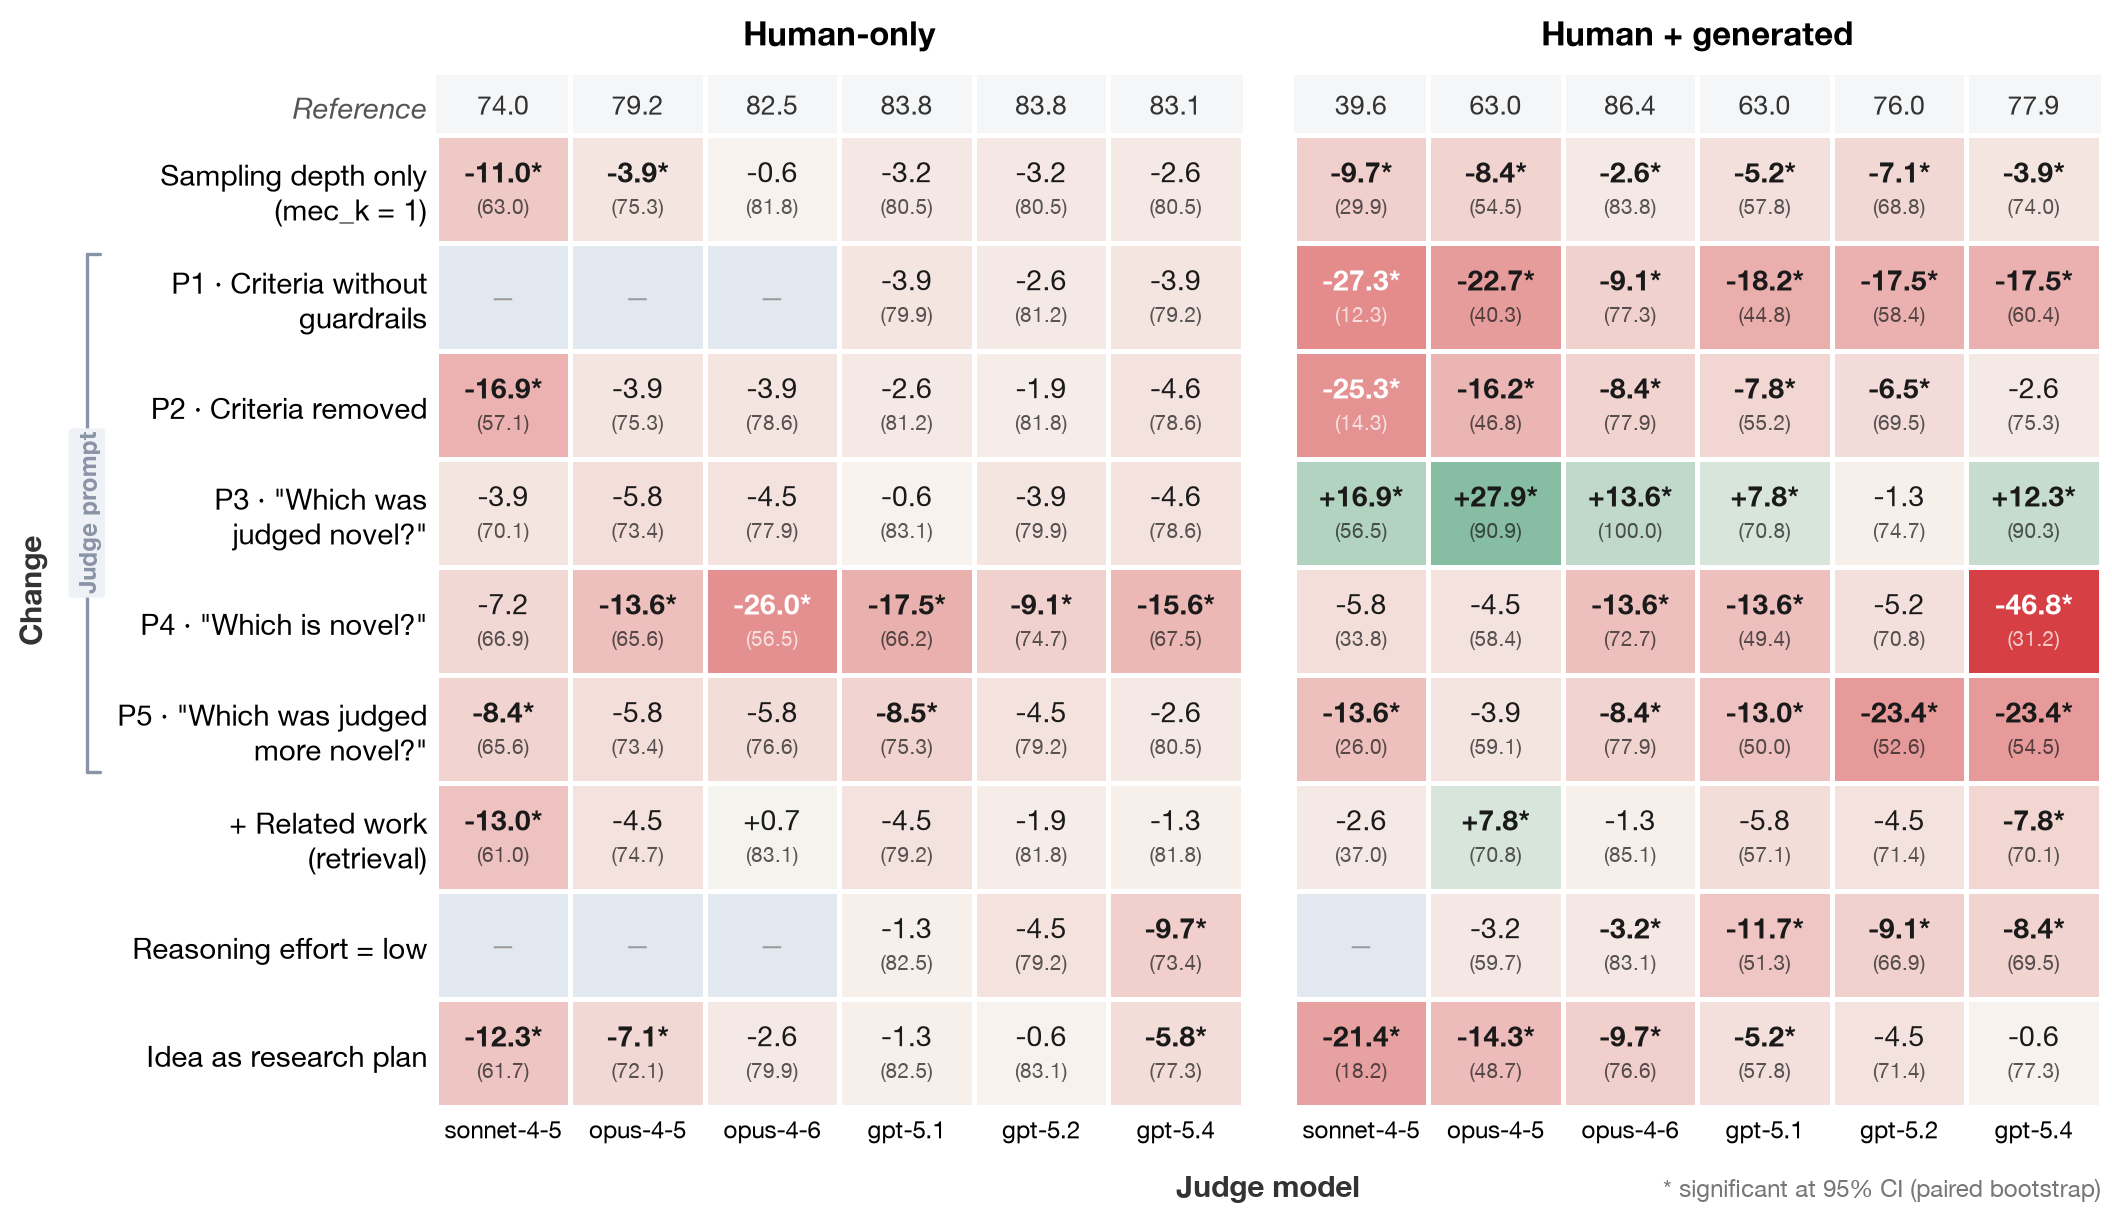

output/figures/sampling-depth/mec-k1_pointwise_filtered_f1_neg.png (+ .pdf)


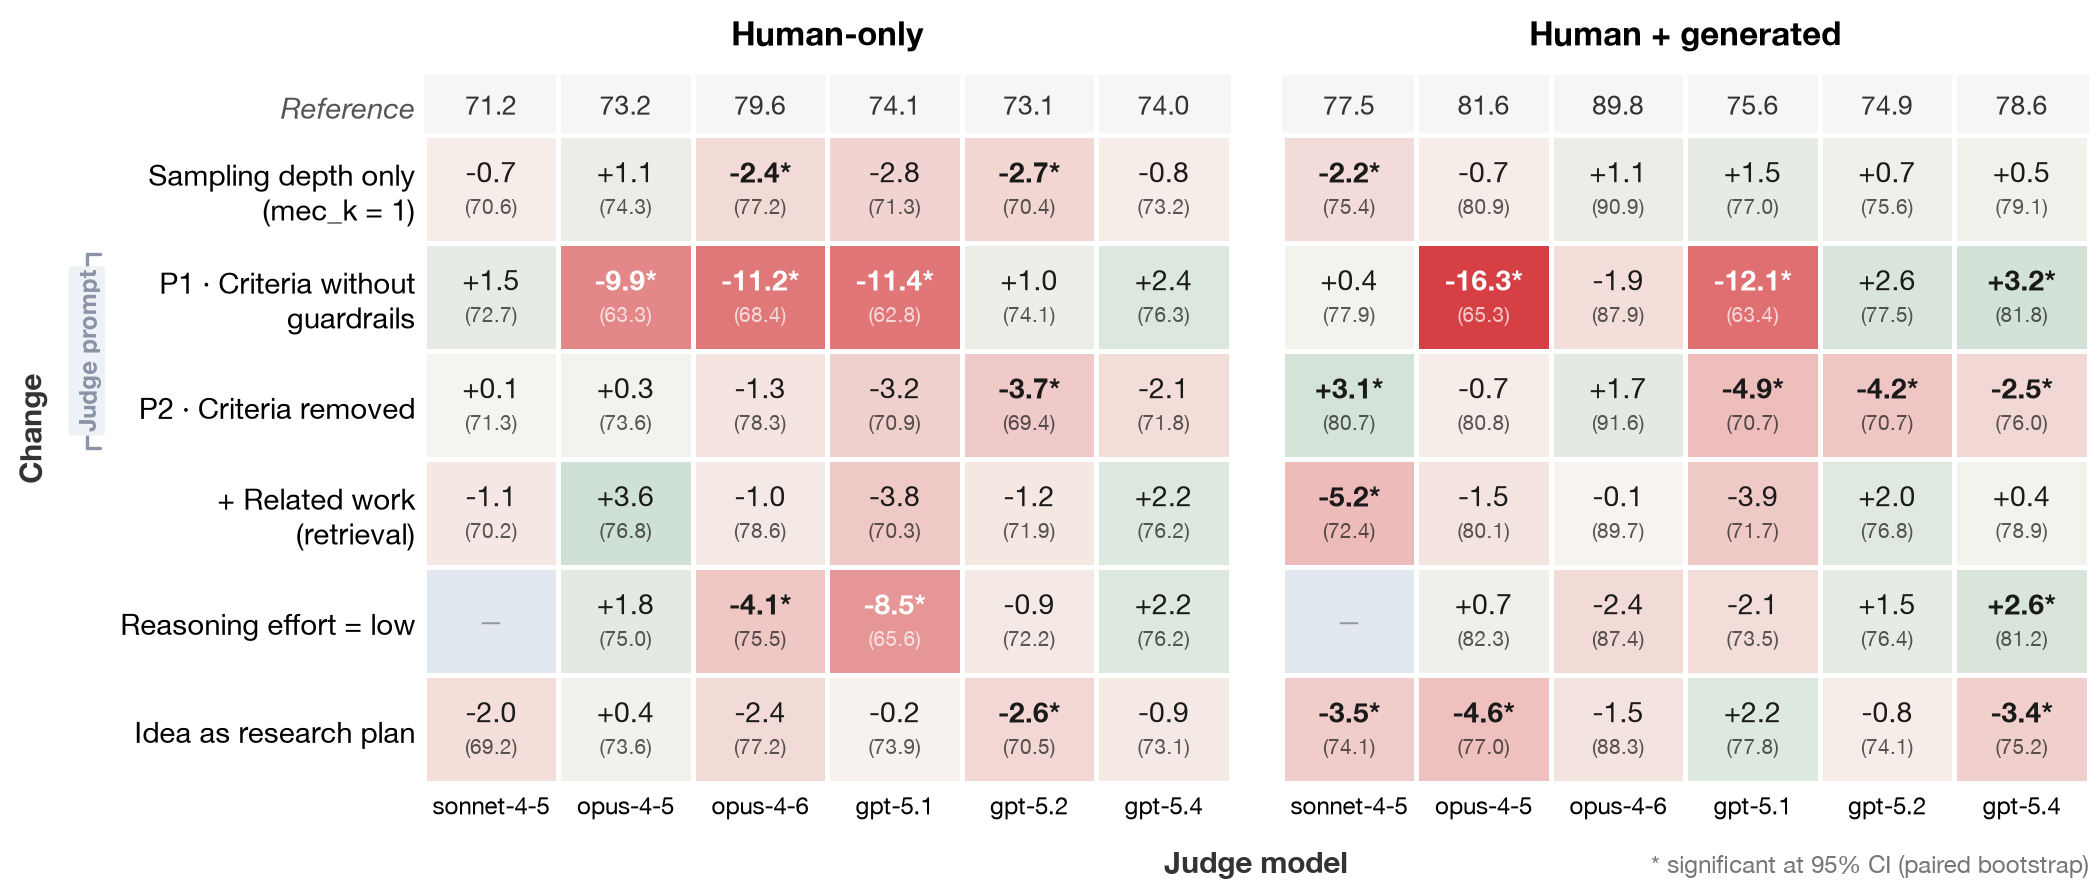

In [26]:
for setup in METRICS:
    png = K1.draw(setup)
    print(png.relative_to(ROOT), "(+ .pdf)")
    display(Image(filename=str(png)))